# Evaluation of Root Heights

In [1]:
from Bio import Nexus, Phylo, SeqIO
from collections import defaultdict
from io import StringIO

import matplotlib.pyplot as plt
from matplotlib import gridspec

import seaborn as sns

import pandas as pd
import numpy as np

import re
from pathlib import Path

from itertools import combinations

from evaluation_helpers import *

In [2]:
input_csv = "../scripts/successful_mcmc_runs.csv" 
overview_df, df_failed = process_results(input_csv)
overview_df.head()

#overview_df_ = add_tree_information(overview_df_)
overview_df_ = pd.read_pickle("../results/run1/evaluation/df_pop_info.pkl")
overview_df_.head()

tree_metrics_combined = pd.read_csv("../results/run1/evaluation/tree_metrics_combined.csv")

root_height_df = get_root_height_df(tree_metrics_combined)
# rel_cum_pop_size_error is relative to the root error, but we also want to see the relative error compared to the simulated cumulative population size
root_height_df['cum_pop_size_abs_error'] = np.abs(root_height_df['cum_pop_size_error'])
root_height_df['cum_pop_size_error_relsim'] = root_height_df['cum_pop_size_error'] / root_height_df['cum_pop_size_sim']
root_height_df_wide = get_root_height_df_wide(root_height_df)

/var/folders/l3/cr7pvqjn2054djbp5cf7qbd40000gn/T/ipykernel_17640/3758191412.py:9: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  tree_metrics_combined = pd.read_csv("../results/run1/evaluation/tree_metrics_combined.csv")


In [5]:
root_height_df.columns

Index(['height_sim', 'height_estimate', 'height_ci_lower_estimate',
       'height_ci_upper_estimate', 'internal', 'height_inside_ci',
       'height_diff', 'height_relative_error', 'height_abs_relative_error',
       'tree_name', 'tree_index', 'model', 'population_model',
       'mutation_signal', 'sampling', 'height_abs_diff', 'present_pop_size',
       'growth_rate', 'bottleneck_size', 'bottleneck_start', 'bottleneck_end',
       'coalescent_median', 'root_height', 'coalescent_lower',
       'coalescent_upper', 'true_pop_size', 'est_pop_size', 'diff_pop_size',
       'abs_diff_pop_size', 'rel_diff_pop_size', 'abs_rel_diff_pop_size',
       'cum_pop_size_sim', 'cum_pop_size_est', 'cum_pop_size_error',
       'root_cum_pop_size_error', 'rel_cum_pop_size_error',
       'cum_pop_size_error_relsim'],
      dtype='object')

## CI overlap

1.  How much do the constcoal and skyline posterior distributions of root height overlap with each other, per condition.
    - Evaluating the overlap (by assuming a normal distribution of the posterior, since I only have the 95% CI borders and not the full posterior) shows that the higher the mutation signal, the higher is the overlap between the CIs. However, the overlap is always high and there is barely no difference between uniform and exponential growth (fast or slow).

2. how oftern do skyline and constcoal cases get confidence intervals that fit the true root height?
    - interesting that bottleneck and uniform case are generally bad
    - for expgrowth we see what we expect
    - heterochronous sampling in general has better fitting CIs than homochronous sampling (better data)

In [4]:
display(evaluate_ci_overlap(root_height_df_wide, sampling="independenthomochronous"))
evaluate_ci_overlap(root_height_df_wide, sampling="linearconstant")

population_model  mutation_signal
uniform           high               0.986645
                  med                0.762277
                  low                0.651657
expgrowthslow     high               0.893322
                  med                0.732832
                  low                0.588558
expgrowthfast     high               0.826073
                  med                0.677874
                  low                0.479965
bottleneck        high               0.757856
Name: overlap, dtype: float64

population_model  mutation_signal
uniform           high               0.989394
                  med                0.725740
                  low                0.657276
expgrowthslow     high               0.890285
                  med                0.676060
                  low                0.639940
expgrowthfast     high               0.802771
                  med                0.652824
                  low                0.607021
bottleneck        high               0.966296
                  med                0.759139
                  low                0.611270
Name: overlap, dtype: float64

In [9]:
print("Percentage of root height estimates inside confidence interval: ")
display(root_height_df[root_height_df['height_inside_ci'] == True].value_counts('model') / (len(root_height_df) / 2))

print("Percentage of root height estimates inside 95% HPD by condition and model:")
(root_height_df.groupby(['population_model', 'mutation_signal', 'sampling', 'model']).apply(lambda g: (g['height_inside_ci'] == True).sum() / len(g)).rename('pct_inside_ci')                                                                                                                                                                                                           .reset_index())             

Percentage of root height estimates inside confidence interval: 


model
skyline      0.701162
constcoal    0.666843
Name: count, dtype: float64

Percentage of root height estimates inside 95% HPD by condition and model:


/var/folders/l3/cr7pvqjn2054djbp5cf7qbd40000gn/T/ipykernel_16732/1935329318.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  (root_height_df.groupby(['population_model', 'mutation_signal', 'sampling', 'model']).apply(lambda g: (g['height_inside_ci'] == True).sum() / len(g)).rename('pct_inside_ci')                                                                                                                                                                                                           .reset_index())


,population_model,mutation_signal,sampling,model,pct_inside_ci
0,bottleneck,high,independenthomochronous,constcoal,0.000000
1,bottleneck,high,independenthomochronous,skyline,0.000000
2,bottleneck,high,linearconstant,constcoal,0.088608
3,bottleneck,high,linearconstant,skyline,0.088608
4,bottleneck,low,linearconstant,constcoal,0.612245
5,bottleneck,low,linearconstant,skyline,0.520408
6,bottleneck,med,linearconstant,constcoal,0.194030
7,bottleneck,med,linearconstant,skyline,0.149254
8,expgrowthfast,high,independenthomochronous,constcoal,0.892473
9,expgrowthfast,high,independenthomochronous,skyline,0.913978


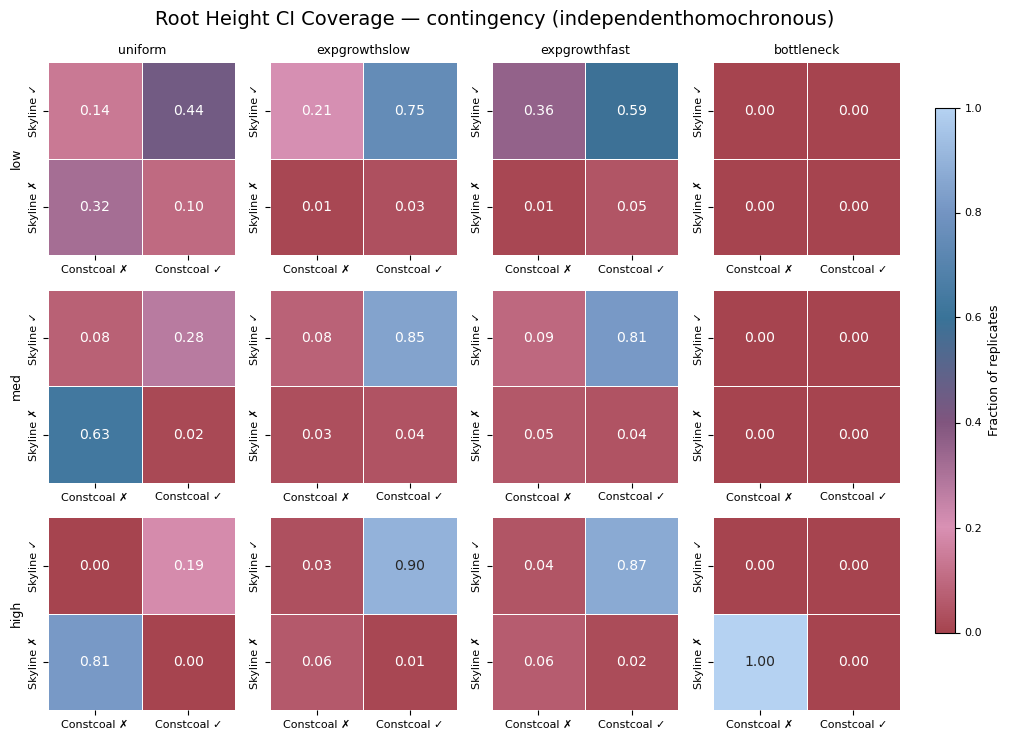

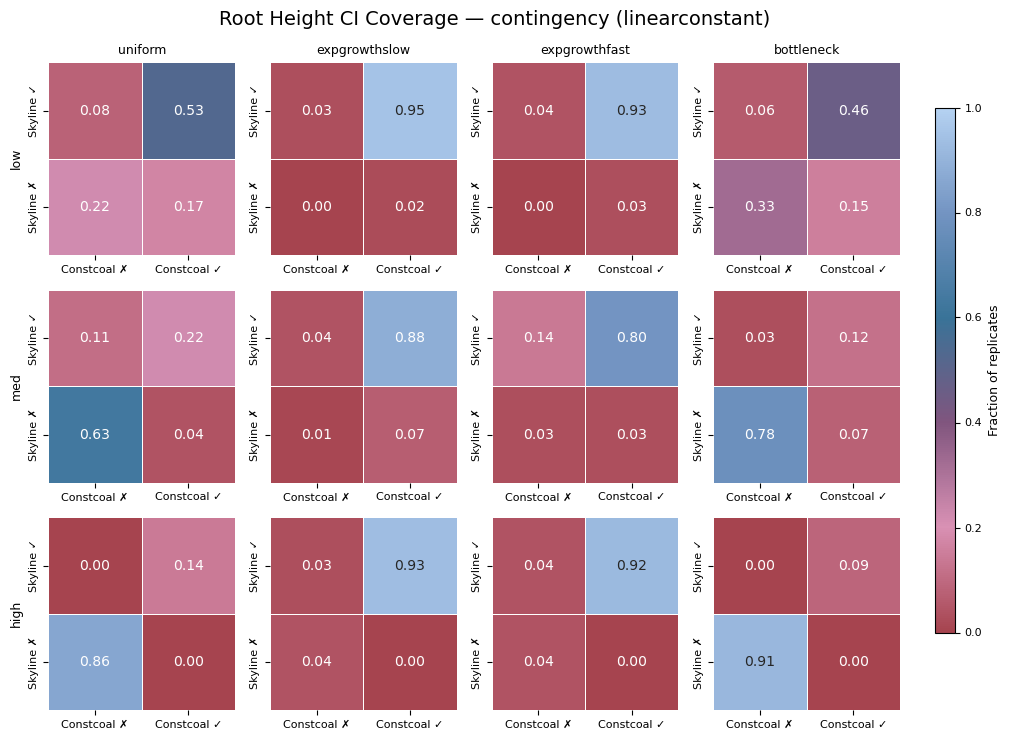

In [3]:
plot_ci_coverage_heatmap(root_height_df_wide)

## Scatter plot showing error in root height depending on cumulative error in population size

Observations:
- uniform error barely changes with mutation signal and no real difference, just more spread in pop_size error for skyline
- while for constcoal case we on average overestimate the population size, for the skyline case we have both effects on average --> root height errors can cancel each other out when summarized as a boxplot
- we see a clear trent for skyline case:
    - underestimated overall population size: underestimated root height
    - overestimated overall population size: overestimated root height
- for bottleneck we generally underestimate root height (especially constcoal) while for exponential growth we overestimate
- for linearconstant case the skyline pop. estimates are quite wrong which is why we get worse results then for the skyline
- bottleneck and uniform root height are much harder to estimate since they are usually very long branches, they also have high errors in high mutation signal case
    - instead for exponential growth we see strong improvement with mutation signal in the estimation

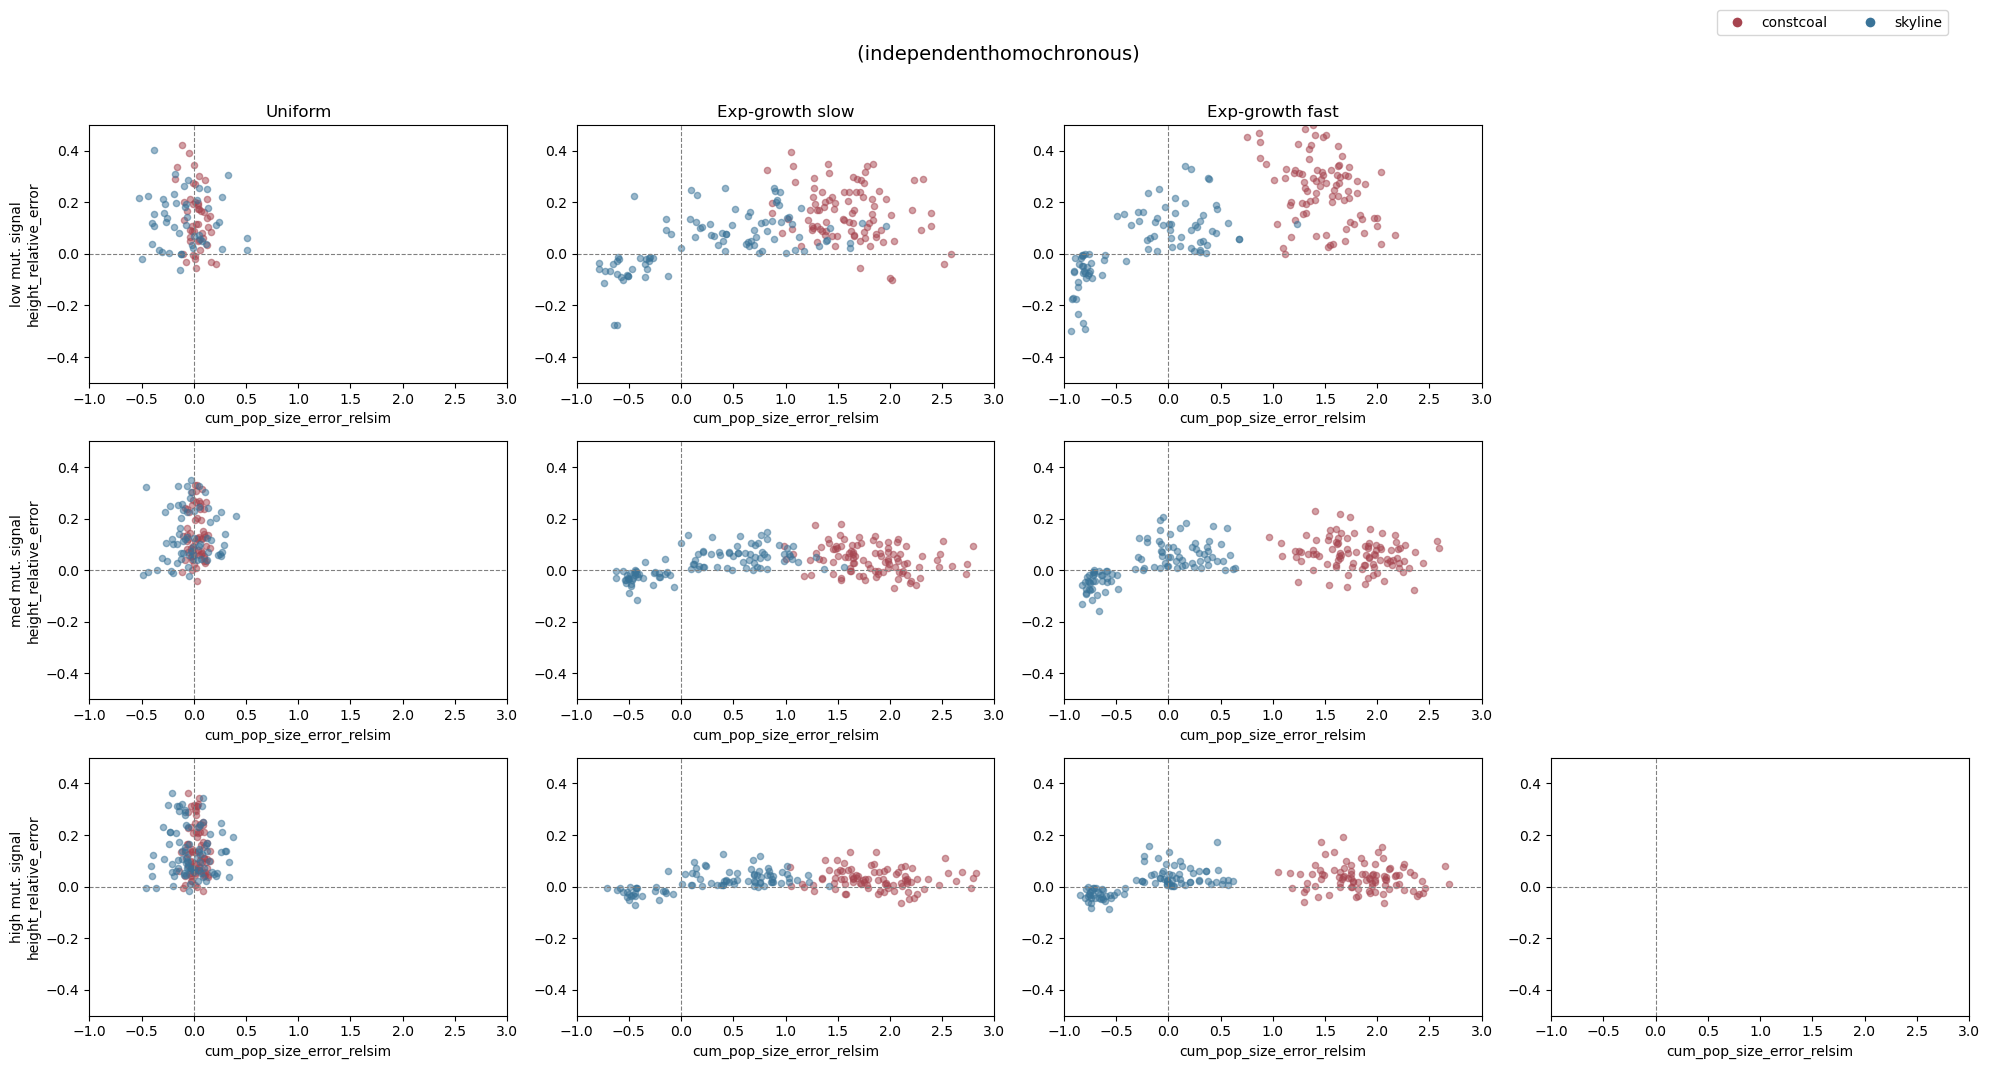

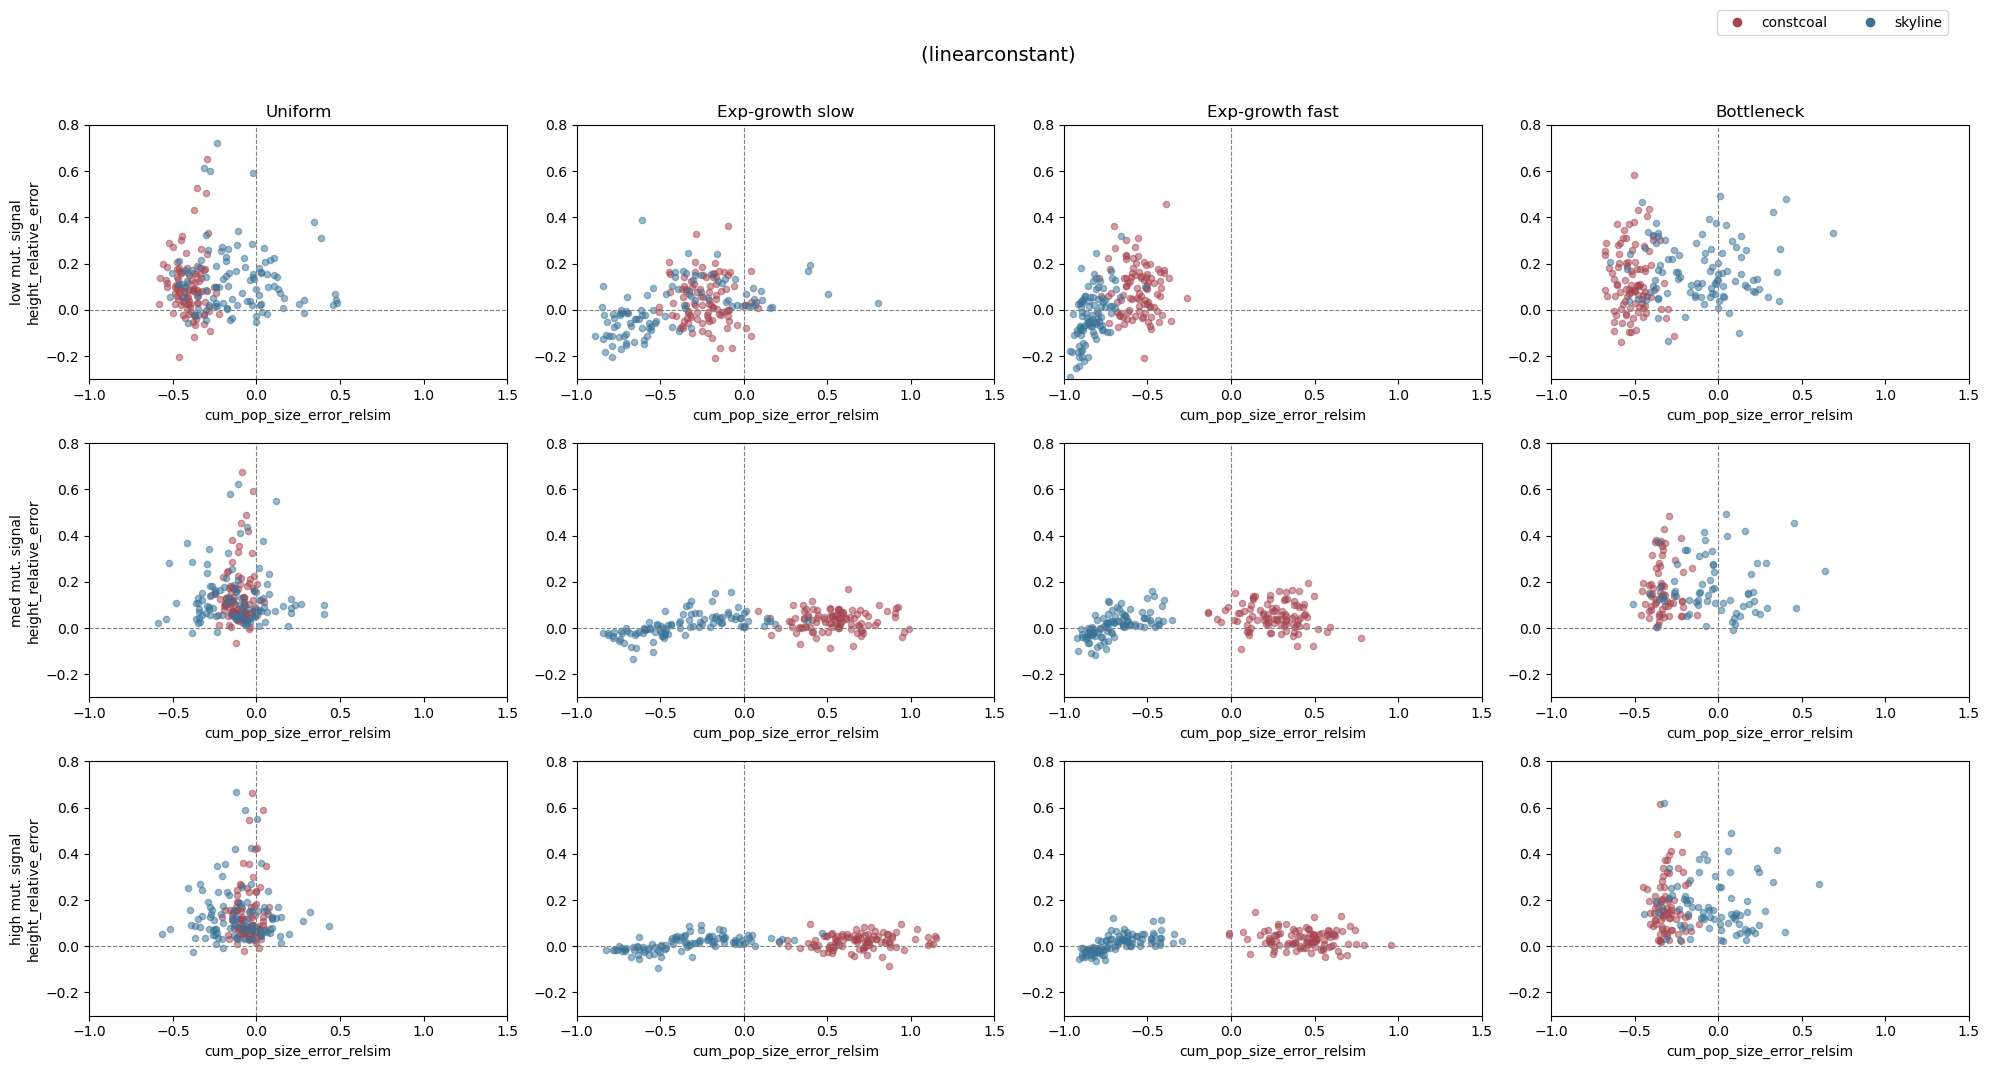

In [4]:
plot_height_vs_popsize_error(root_height_df_wide, sampling="independenthomochronous", x_col="cum_pop_size_error_relsim", y_col="height_relative_error", alpha = 0.5, s = 20, x_range = (-1,3), y_range = (-0.5, 0.5))
plot_height_vs_popsize_error(root_height_df_wide, sampling="linearconstant", x_col="cum_pop_size_error_relsim", y_col="height_relative_error", alpha = 0.5, s = 20, x_range = (-1,1.5), y_range = (-0.3, 0.8))

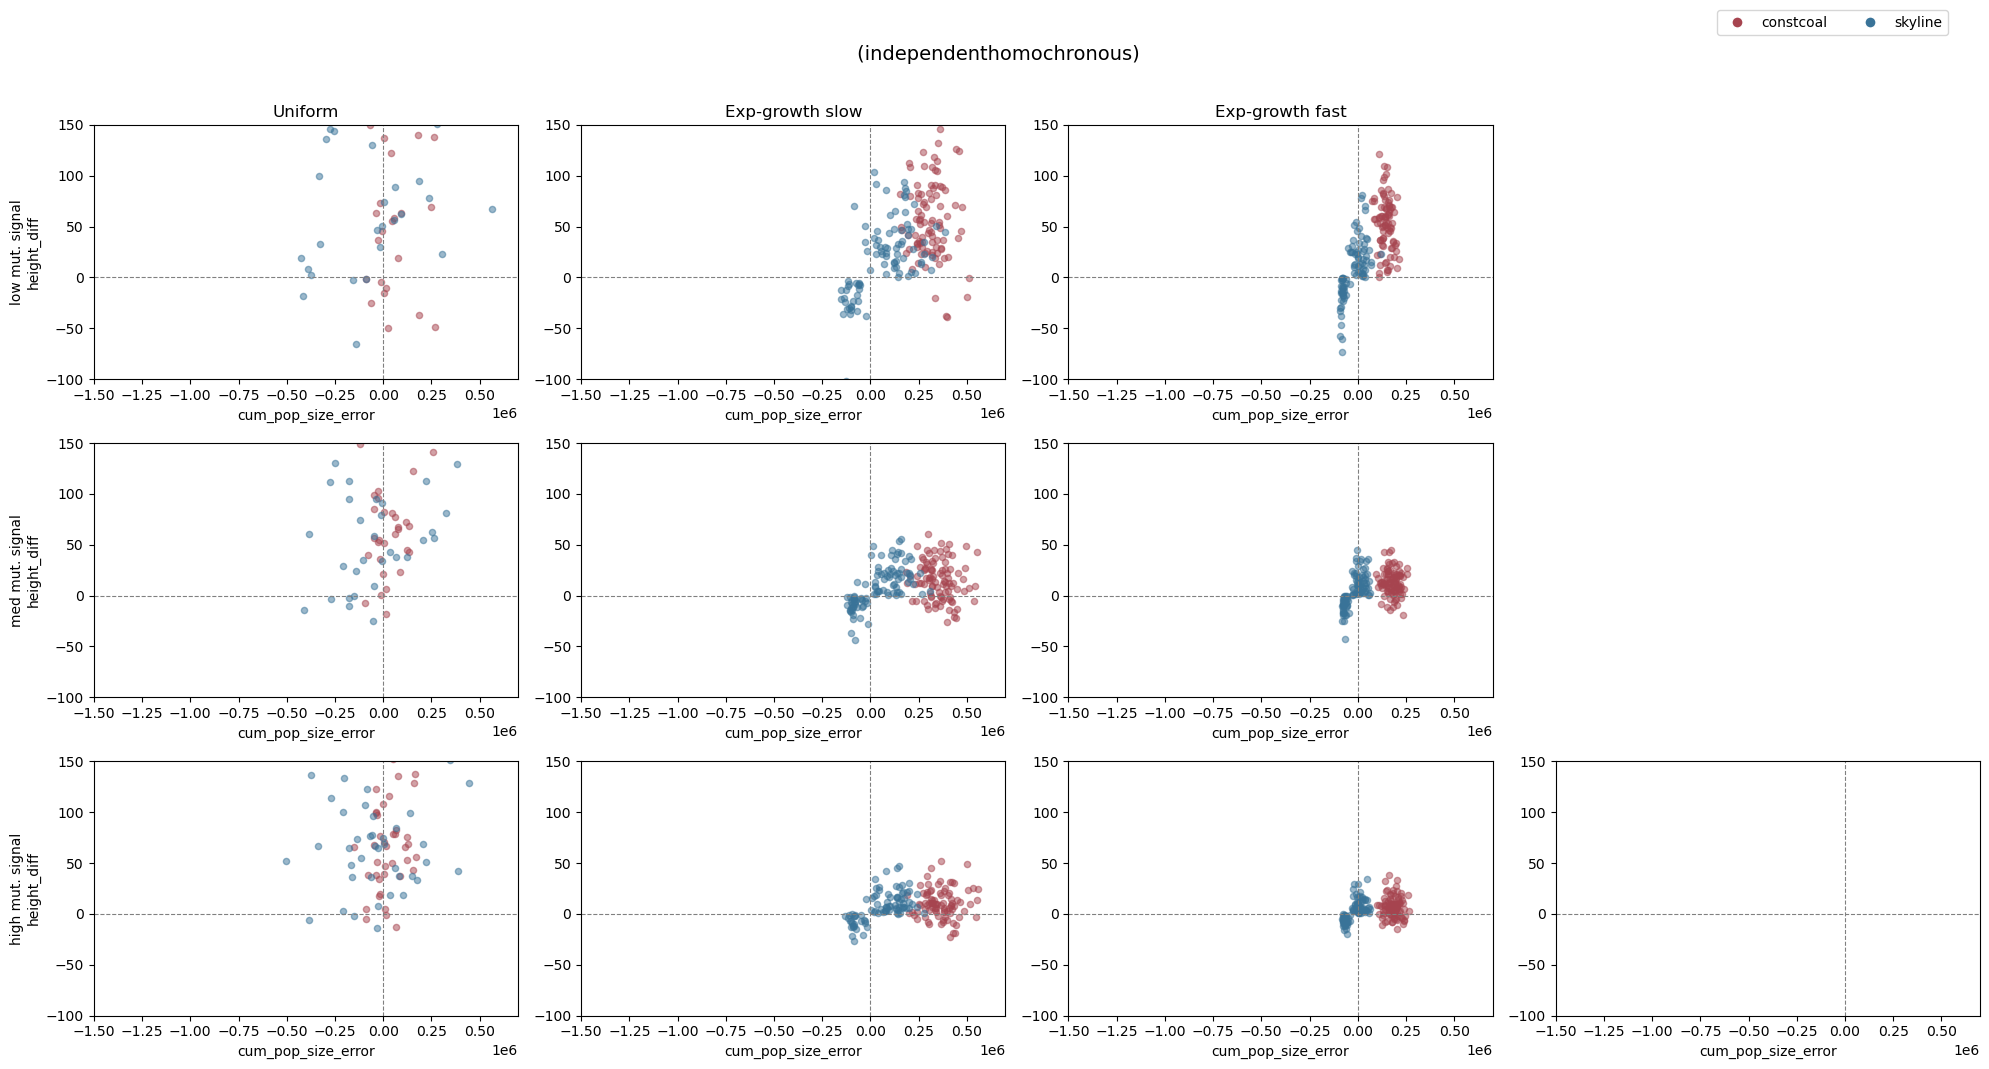

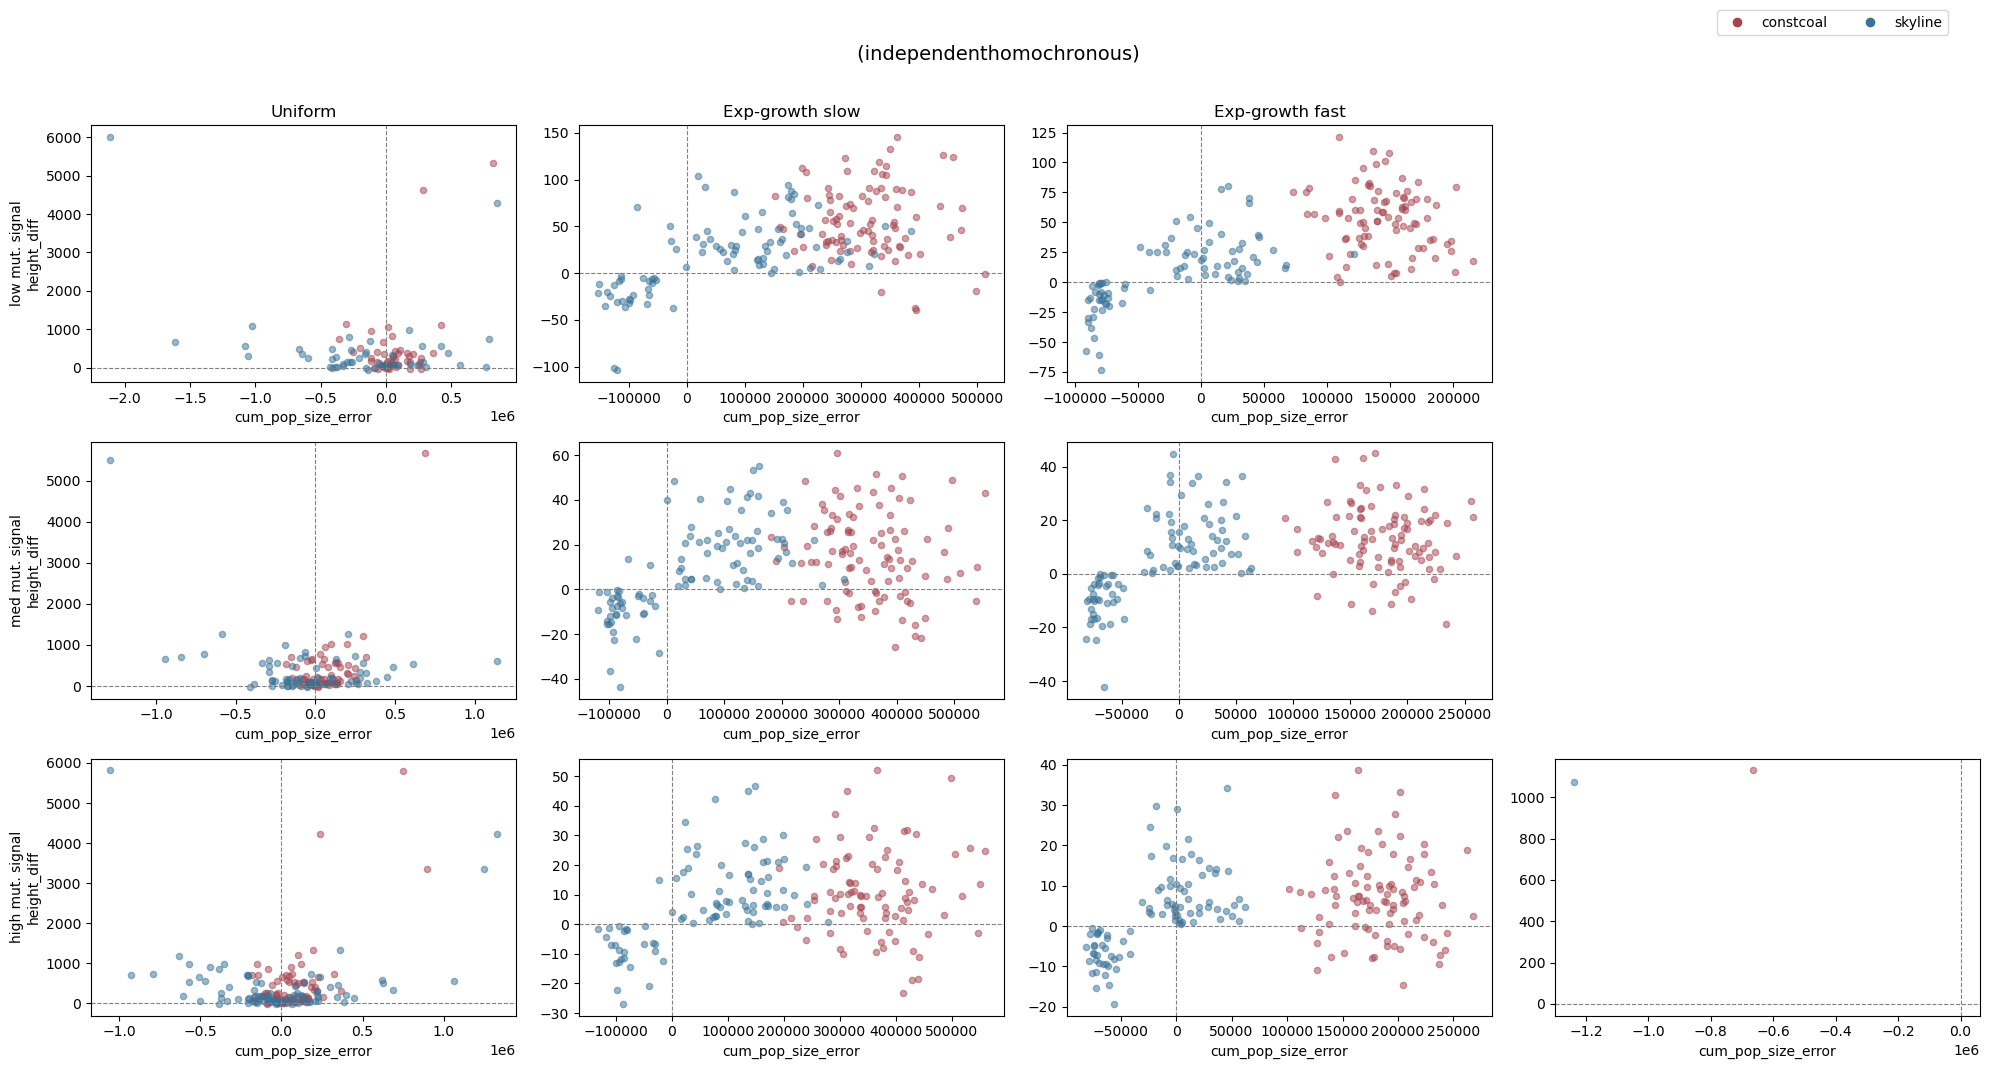

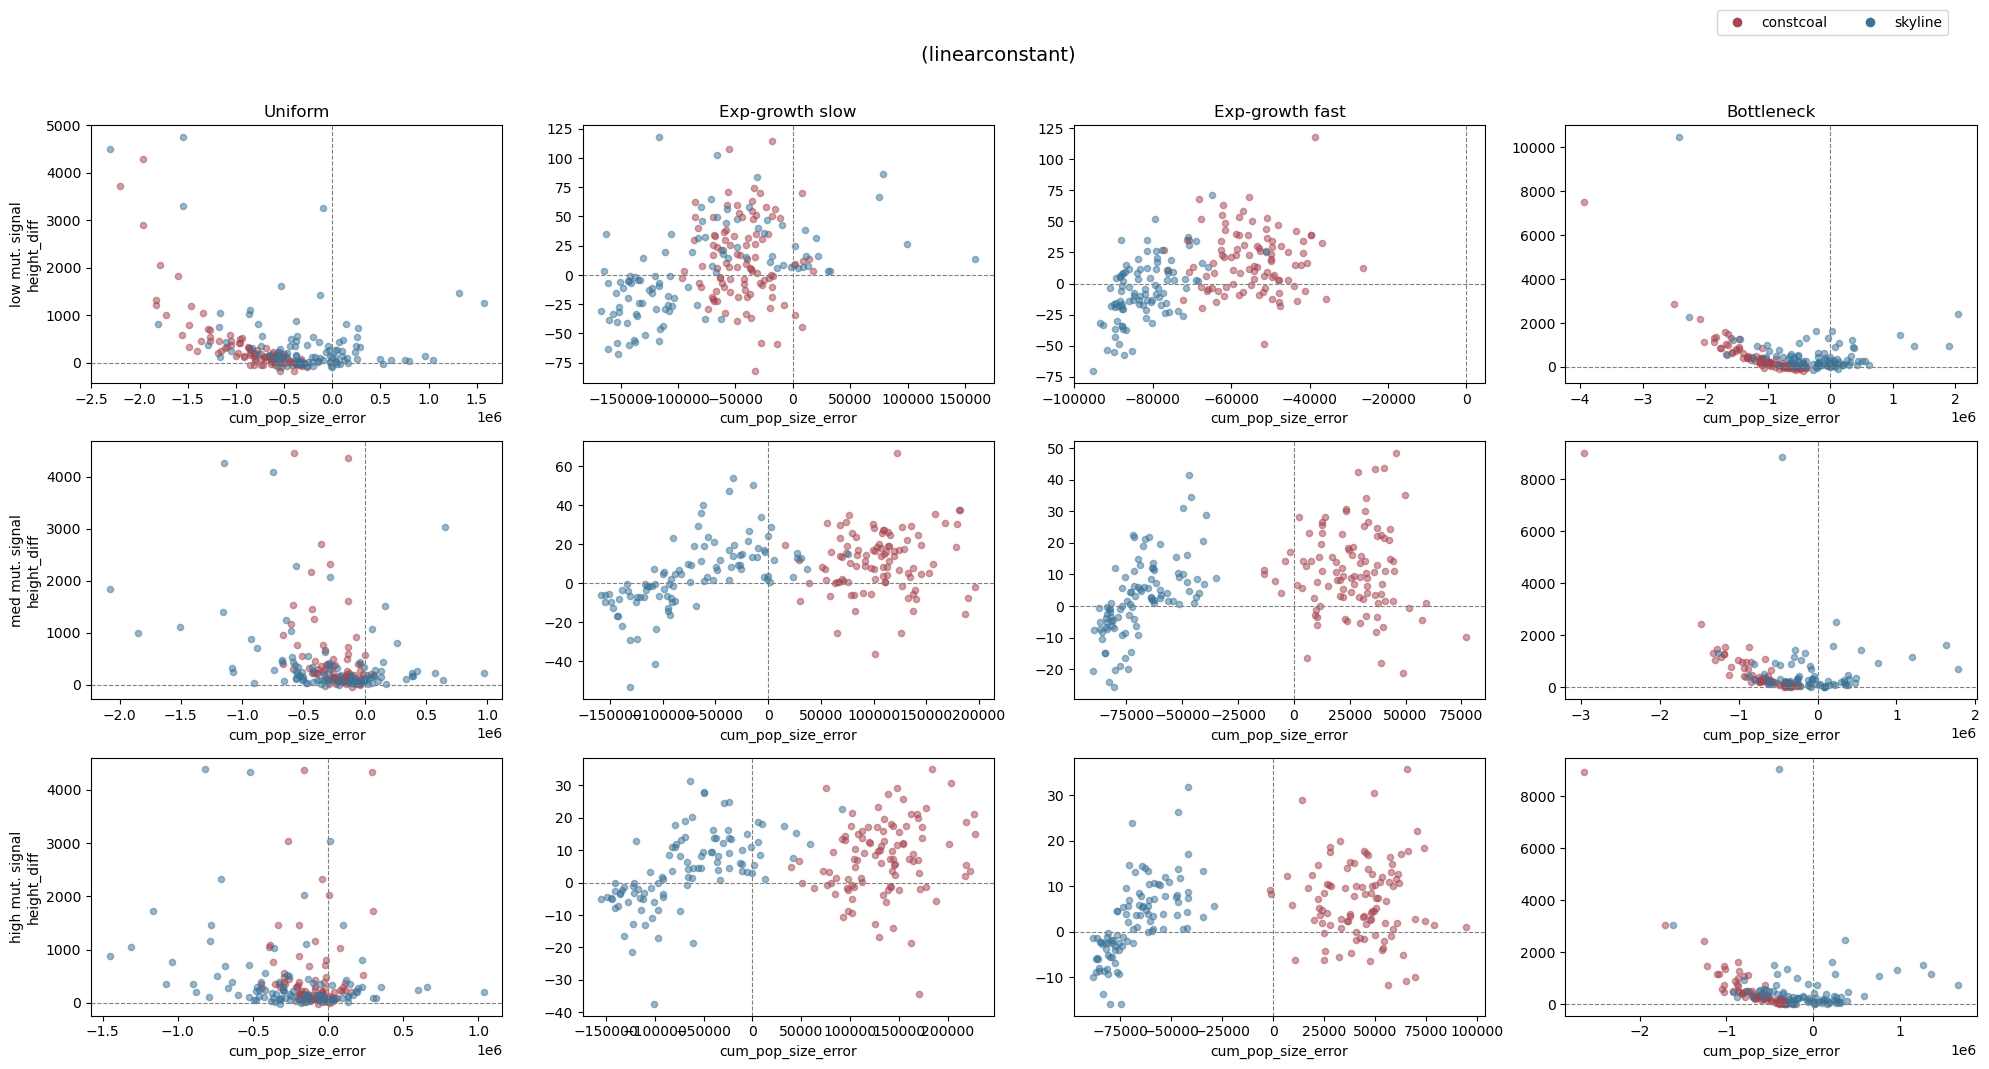

In [5]:
plot_height_vs_popsize_error(root_height_df_wide, sampling="independenthomochronous", x_col="cum_pop_size_error", y_col="height_diff", alpha = 0.5, s = 20, x_range = (-1.5e6, 0.7e6), y_range = (-100, 150))   
plot_height_vs_popsize_error(root_height_df_wide, sampling="independenthomochronous", x_col="cum_pop_size_error", y_col="height_diff", alpha = 0.5, s = 20)       
plot_height_vs_popsize_error(root_height_df_wide, sampling="linearconstant", x_col="cum_pop_size_error", y_col="height_diff", alpha = 0.5, s = 20)

In [4]:
#plot_height_vs_popsize_error(root_height_df_wide, sampling="independenthomochronous", x_col="cum_pop_size_abs_error", y_col="height_abs_diff", alpha = 0.5, s = 20)       
#plot_height_vs_popsize_error(root_height_df_wide, sampling="linearconstant", x_col="cum_pop_size_abs_error", y_col="height_abs_diff", alpha = 0.5, s = 20)

## Box plot that summarizes all root heights

Problem: absolute errors influence each other since we see positive and negative effect for skyline and only positive errors for constcoal.

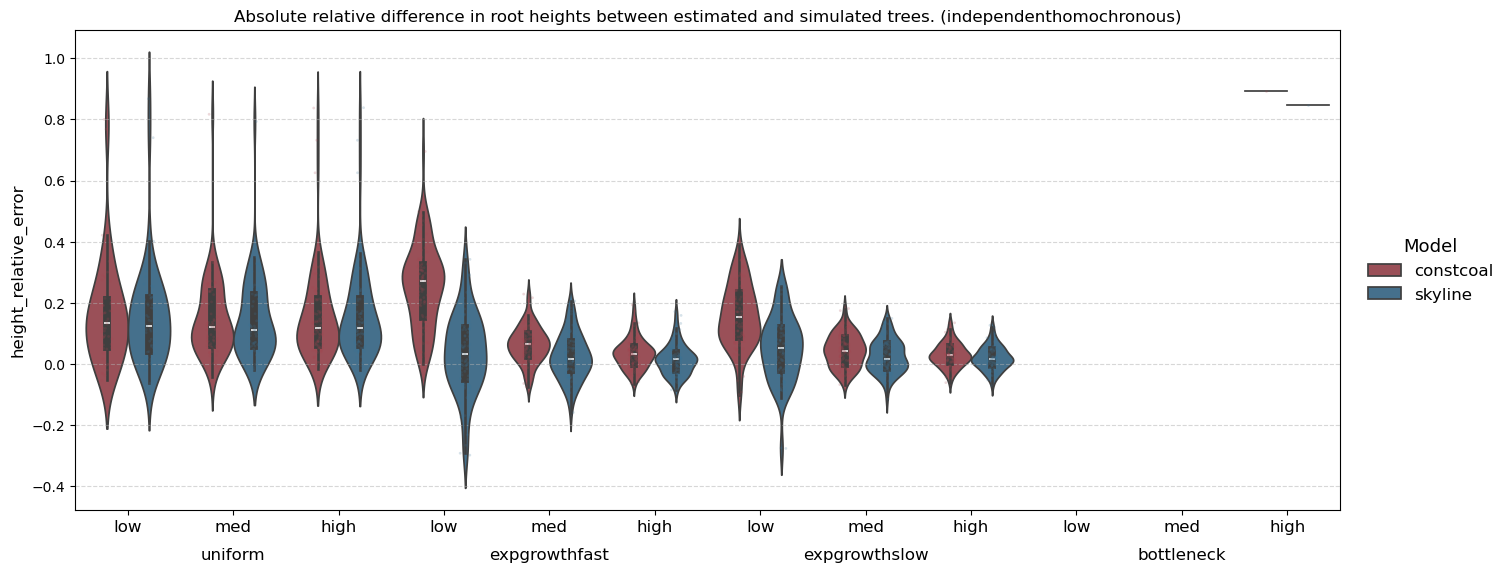

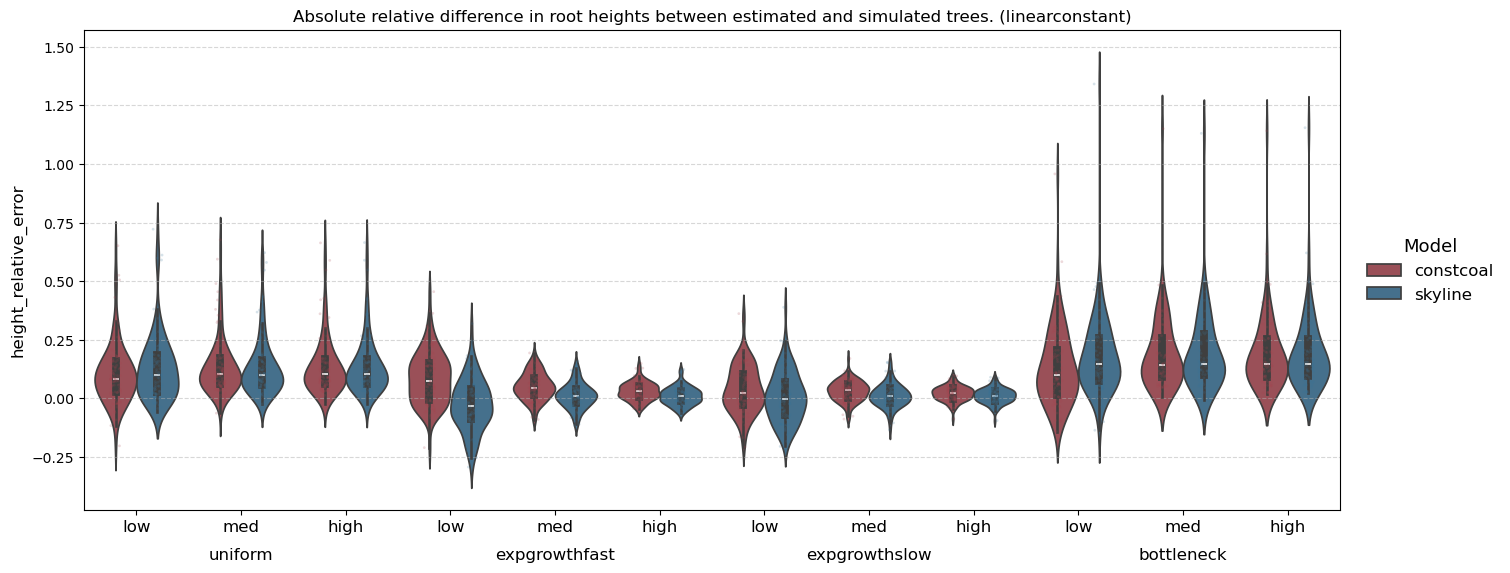

In [5]:
boxplot_branch_length_errors(root_height_df, sampling='independenthomochronous', metric='height_relative_error', title = 'Absolute relative difference in root heights between estimated and simulated trees.', plot_type='violin', logscale = False)
boxplot_branch_length_errors(root_height_df, sampling='linearconstant', metric='height_relative_error', title = 'Absolute relative difference in root heights between estimated and simulated trees.', plot_type='violin', logscale = False)

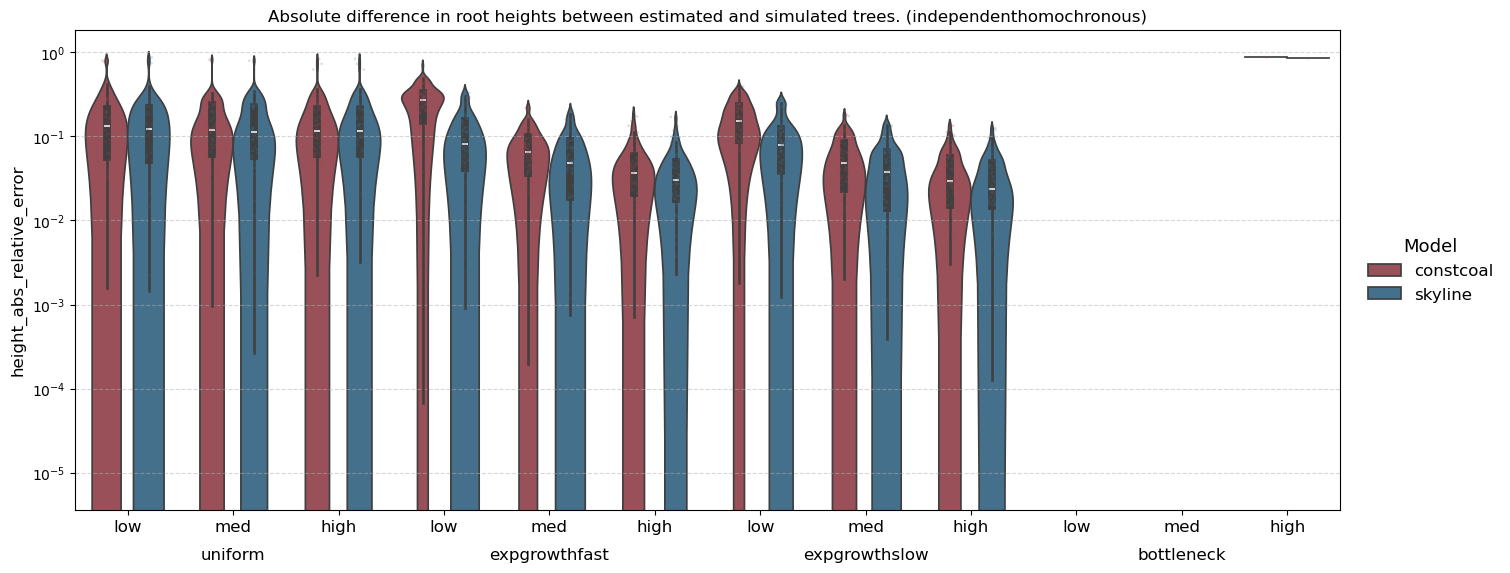

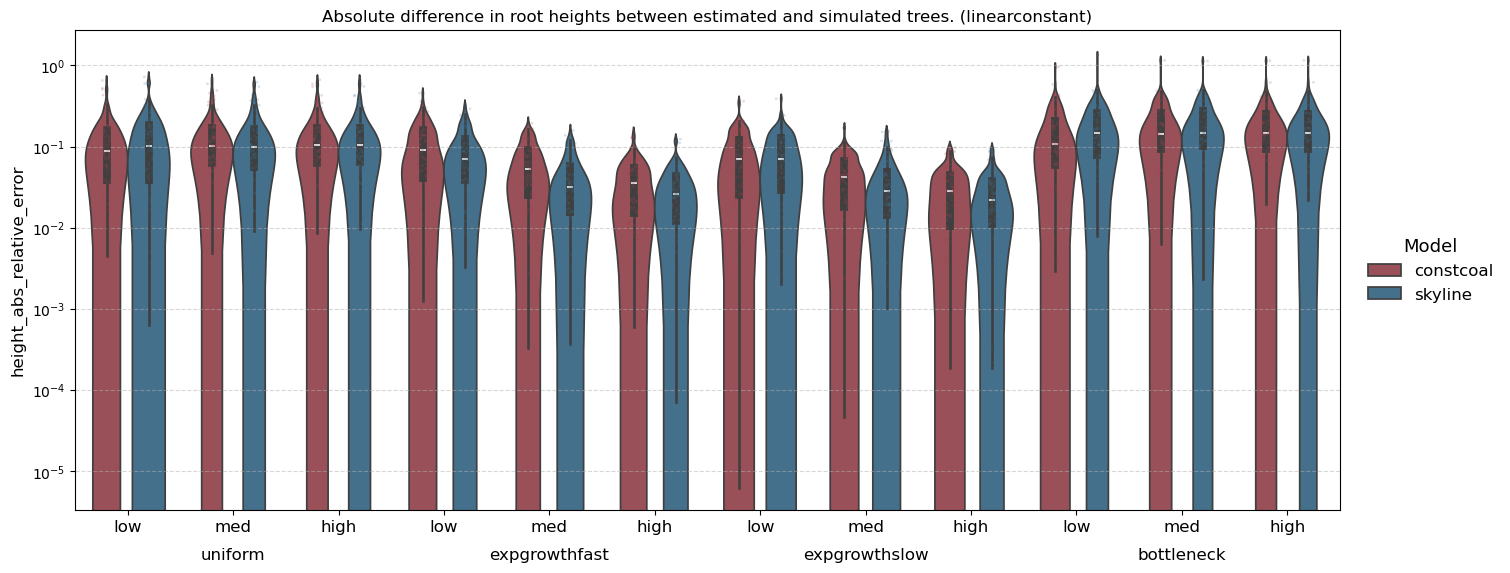

In [8]:
boxplot_branch_length_errors(root_height_df, sampling='independenthomochronous', metric='height_abs_relative_error', title = 'Absolute difference in root heights between estimated and simulated trees.', plot_type = 'violin')
boxplot_branch_length_errors(root_height_df, sampling='linearconstant', metric='height_abs_relative_error', title = 'Absolute difference in root heights between estimated and simulated trees.', plot_type = 'violin')

## Wilcoxon signed rank tests

Wilcoxon signed rank test based on (relative) differences and absolute (relative) differences are both strongly significant for the high mutational signal (fast and slow exponential growth setting) and significant for the low mutational signal for fast exponential growth.

In [4]:
run_wilcoxon_test(root_height_df_wide, sampling = "independenthomochronous", col_to_compare_constcoal = 'height_diff_constcoal', col_to_compare_skyline = 'height_diff_skyline')
print()
run_wilcoxon_test(root_height_df_wide, sampling = "linearconstant", col_to_compare_constcoal = 'height_diff_constcoal', col_to_compare_skyline = 'height_diff_skyline')

Wilcoxon test result of uniform population model and with low mutation signal of height_diff_constcoal: WilcoxonResult(statistic=np.float64(621.0), pvalue=np.float64(0.878334307774896))
Wilcoxon test result of uniform population model and with med mutation signal of height_diff_constcoal: WilcoxonResult(statistic=np.float64(1066.0), pvalue=np.float64(0.9661183804924444))
Wilcoxon test result of uniform population model and with high mutation signal of height_diff_constcoal: WilcoxonResult(statistic=np.float64(1202.0), pvalue=np.float64(0.003994965992929861))
Wilcoxon test result of expgrowthfast population model and with low mutation signal of height_diff_constcoal: WilcoxonResult(statistic=np.float64(193.0), pvalue=np.float64(3.242034134554051e-13))
Wilcoxon test result of expgrowthfast population model and with med mutation signal of height_diff_constcoal: WilcoxonResult(statistic=np.float64(695.0), pvalue=np.float64(2.4093170779895304e-09))
Wilcoxon test result of expgrowthfast popu

/opt/homebrew/Caskroom/miniforge/base/envs/beast-tools/lib/python3.11/site-packages/scipy/_lib/_util.py:798: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return fun(*args, **kwargs)


In [5]:
# run wilcoxon signed rank test on absolute relative errors in root height for independent homochronous sampling
run_wilcoxon_test(root_height_df_wide, sampling = "independenthomochronous", col_to_compare_constcoal = 'height_abs_relative_error_constcoal', col_to_compare_skyline = 'height_abs_relative_error_skyline')
print()
# run wilcoxon signed rank test on relative errors in root height
run_wilcoxon_test(root_height_df_wide, sampling = "independenthomochronous", col_to_compare_constcoal = 'height_relative_error_constcoal', col_to_compare_skyline = 'height_relative_error_skyline')
print()

# test is paired: don't need relative errors
# run wilcoxon signed rank test on absolute errors in root height
run_wilcoxon_test(root_height_df_wide, sampling = "independenthomochronous", col_to_compare_constcoal = 'height_abs_diff_constcoal', col_to_compare_skyline = 'height_abs_diff_skyline')
print()
# run wilcoxon signed rank test on errors in root height
run_wilcoxon_test(root_height_df_wide, sampling = "independenthomochronous", col_to_compare_constcoal = 'height_diff_constcoal', col_to_compare_skyline = 'height_diff_skyline')

print()
print()

# run wilcoxon signed rank test on absolute relative errors in root height for linearconstant sampling
run_wilcoxon_test(root_height_df_wide, sampling = "linearconstant", col_to_compare_constcoal = 'height_abs_relative_error_constcoal', col_to_compare_skyline = 'height_abs_relative_error_skyline')
print()
# run wilcoxon signed rank test on relative errors in root height
run_wilcoxon_test(root_height_df_wide, sampling = "linearconstant", col_to_compare_constcoal = 'height_relative_error_constcoal', col_to_compare_skyline = 'height_relative_error_skyline')
print()

# test is paired: don't need relative errors
# run wilcoxon signed rank test on absolute errors in root height
run_wilcoxon_test(root_height_df_wide, sampling = "linearconstant", col_to_compare_constcoal = 'height_abs_diff_constcoal', col_to_compare_skyline = 'height_abs_diff_skyline')
print()
# run wilcoxon signed rank test on errors in root height
run_wilcoxon_test(root_height_df_wide, sampling = "linearconstant", col_to_compare_constcoal = 'height_diff_constcoal', col_to_compare_skyline = 'height_diff_skyline')


Wilcoxon test result of uniform population model and with low mutation signal of height_abs_relative_error_constcoal: WilcoxonResult(statistic=np.float64(575.0), pvalue=np.float64(0.5526669770606443))
Wilcoxon test result of uniform population model and with med mutation signal of height_abs_relative_error_constcoal: WilcoxonResult(statistic=np.float64(1035.0), pvalue=np.float64(0.8064099017681527))
Wilcoxon test result of uniform population model and with high mutation signal of height_abs_relative_error_constcoal: WilcoxonResult(statistic=np.float64(1133.0), pvalue=np.float64(0.0014948948639418756))
Wilcoxon test result of expgrowthfast population model and with low mutation signal of height_abs_relative_error_constcoal: WilcoxonResult(statistic=np.float64(417.0), pvalue=np.float64(2.3597944200433476e-10))
Wilcoxon test result of expgrowthfast population model and with med mutation signal of height_abs_relative_error_constcoal: WilcoxonResult(statistic=np.float64(1645.0), pvalue=np.f